# 08: Tables and Figures

Converts the Week 6 analysis CSVs into defense-ready outputs: APA 7
tables (built in Word from these exports) and 300 DPI publication
figures (matplotlib). Selects the in-text subset for Ch. 4 and
inventories the remainder for Appendices A (tables) and B (figures).

Sources: results_master.csv plus the Section 1-7 analysis exports.
Nothing in this notebook computes new statistics; it renders what
notebook 07 established.

## Figure standards

Fixed for every figure in the study:

- 300 DPI PNG export (APA 7 and ProQuest reproduction requirements)
- Grayscale-safe: minimization levels distinguished by marker shape
  and line style, never color; verified by grayscale test print
- Sans-serif (Arial/DejaVu), 11 pt; no in-figure titles (figure number,
  title, and note live in the Word document per APA convention)
- Error bars: standard error of the mean across the 60 observations
  per cell
- Horizontal dodging: the four minimization-level markers are offset
  +/-0.12 and +/-0.04 around each x position so coincident trajectories
  remain individually legible; x-ticks stay on integer positions. Every
  figure using the dodge carries an APA note disclosing the offset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

BUCKET = "osilesi-dissertation-data-2026"
res = pd.read_csv(f"s3://{BUCKET}/results/results_master.csv")

res["imbalance"] = pd.Categorical(res["imbalance"],
    ["50/50", "80/20", "90/10", "95/5"], ordered=True)
res["min_level"] = pd.Categorical(res["min_level"].astype(str),
    ["100", "75", "50", "25"], ordered=True)

# APA-aligned figure defaults, set once
mpl.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 300,
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 11, "axes.titlesize": 11, "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

## Interaction plot function

One reusable function; every figure in the set is a variation of it.
STYLE maps each minimization level to (marker, linestyle, x-offset);
any cell consuming STYLE must unpack all three values. Markers enlarged
(9 pt, white face) with thinned lines (1.1) so marker identity reads at
print size. Fairness figures pass note_sign=True to draw the zero
reference line required by the signed female-minus-male convention.

In [3]:
STYLE = {  # min_level: (marker, linestyle)
    "100": ("o", "-"), "75": ("s", "--"),
    "50": ("^", "-."), "25": ("D", ":"),
}

## Interaction plot function

One reusable function; every figure in the set is a variation of it.
STYLE maps each minimization level to (marker, linestyle, x-offset);
any cell consuming STYLE must unpack all three values. Markers enlarged
(9 pt, white face) with thinned lines (1.1) so marker identity reads at
print size. Fairness figures pass note_sign=True to draw the zero
reference line required by the signed female-minus-male convention.

In [8]:
STYLE = {  # min_level: (marker, linestyle, x-offset)
    "100": ("o", "-",  -0.12),
    "75":  ("s", "--", -0.04),
    "50":  ("^", "-.",  0.04),
    "25":  ("D", ":",   0.12),
}

def interaction_plot(df, dv, ylabel, fname, note_sign=False):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    for lvl in ["100", "75", "50", "25"]:
        sub = df[df["min_level"] == lvl]
        g = sub.groupby("imbalance", observed=True)[dv]
        means, sems = g.mean(), g.sem()
        m, ls, dx = STYLE[lvl]
        x = [i + dx for i in range(4)]          # dodged positions
        ax.errorbar(x, means, yerr=sems, marker=m, linestyle=ls,
                    color="black", markerfacecolor="white",
                    markersize=9,               # was default ~6
                    markeredgewidth=1.4,
                    linewidth=1.1,              # thinner lines, markers pop
                    capsize=3, label=f"{lvl}% retained")

    ax.set_xticks(range(4))
    ax.set_xticklabels(["50/50", "80/20", "90/10", "95/5"])
    ax.set_xlabel("Class imbalance ratio (majority/minority)")
    ax.set_ylabel(ylabel)
    if note_sign:
        ax.axhline(0, color="gray", linewidth=0.8)
    ax.legend(title="Data minimization level")
    fig.tight_layout()
    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

## Figure set generation

Six single-metric interaction figures (five performance, one fairness),
all candidates first, in-text selection second.

Compositional note recorded before selection: on all five performance
figures the four minimization trajectories are nearly coincident at
every imbalance ratio. This is the finding, not a rendering artifact:
it is the visual statement of the null minimization main effect and
interaction (F <= 0.11, p >= .955). No separation is engineered (no
y-axis windowing, no color, no weight contrast); dodged markers provide
legibility without editorializing. Each performance figure's Word note
carries the disclosure: "The four minimization-level trajectories are
nearly coincident at every imbalance ratio, consistent with the
non-significant minimization main effect and interaction; markers are
horizontally offset for legibility."

fig_eod is the one figure with genuine visible separation (the 25%
trajectory rising to +0.005 under 95/5, wide error bar reflecting
harsh-cell granularity at n = 8 female positives). Its note frames the
pattern as exploratory, consistent with the non-significant omnibus
interaction (F(9, 944) = 0.74, p = .676) and the Supplementary
Findings treatment of the within-95/5 Tukey pairs.

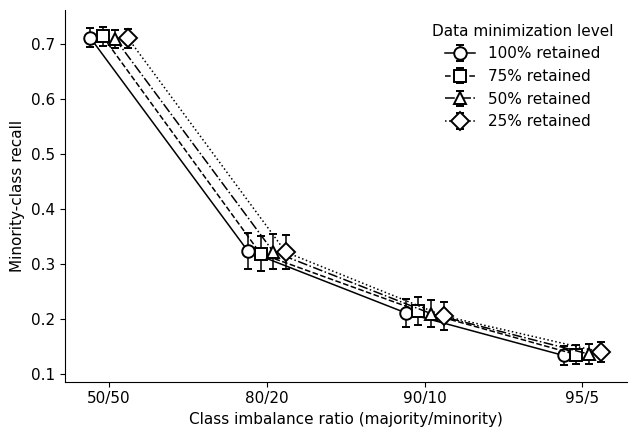

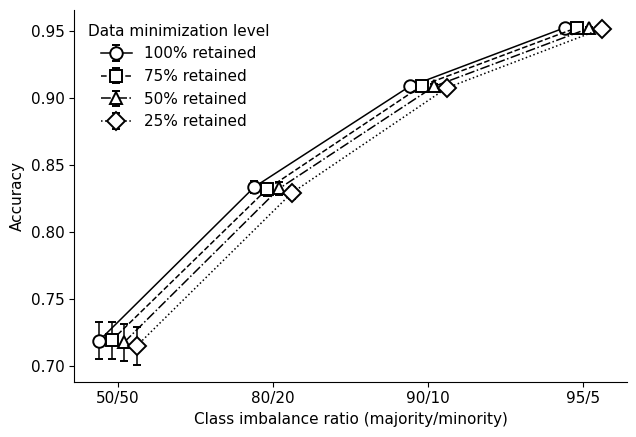

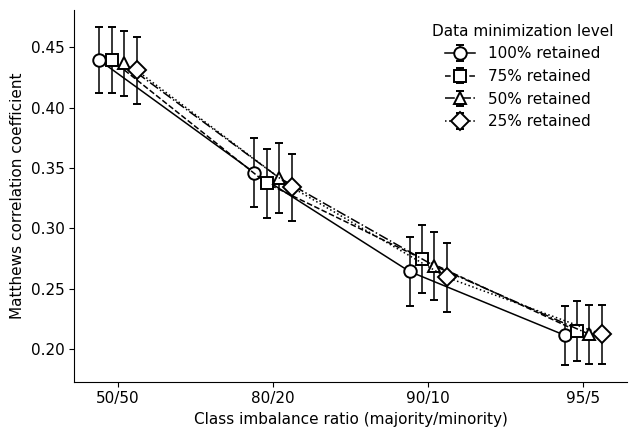

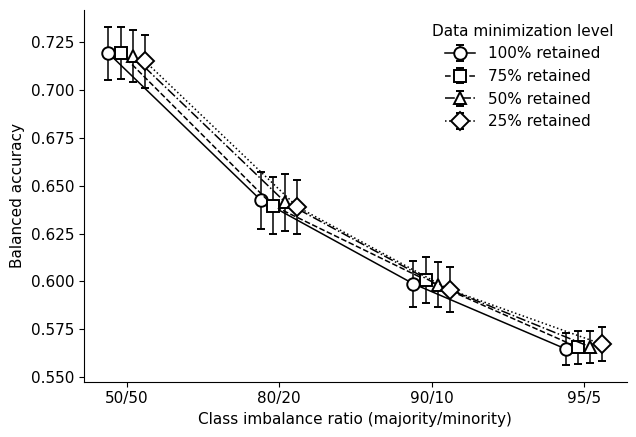

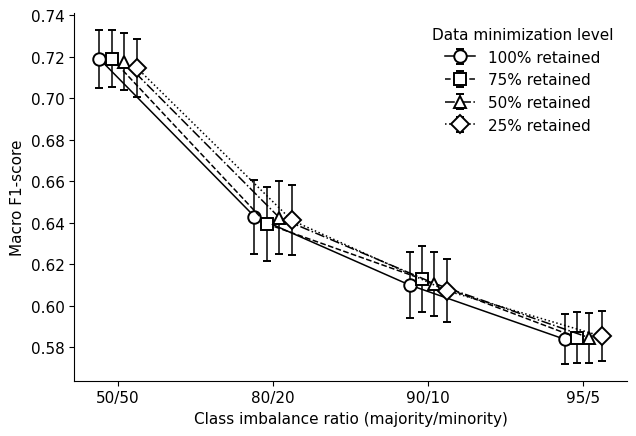

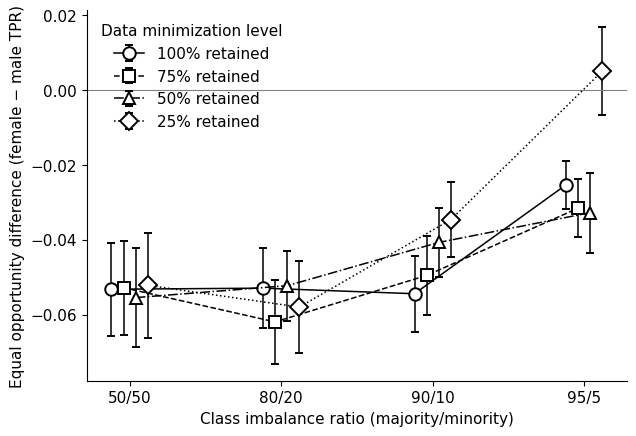

In [9]:
figures = [
    ("minority_recall", "Minority-class recall", "fig_recall.png", False),
    ("accuracy", "Accuracy", "fig_accuracy.png", False),
    ("mcc", "Matthews correlation coefficient", "fig_mcc.png", False),
    ("balanced_accuracy", "Balanced accuracy", "fig_balacc.png", False),
    ("macro_f1", "Macro F1-score", "fig_macrof1.png", False),
    ("equal_opportunity_diff",
     "Equal opportunity difference (female − male TPR)",
     "fig_eod.png", True),
]
for dv, ylab, fname, sign in figures:
    interaction_plot(res, dv, ylab, fname, note_sign=sign)

## RQ3 contrast composite

Two panels, shared y-axis (deliberate: accuracy climbing while
minority recall collapses on the same scale is the RQ3 finding in a
single image), same dodge and marker standards as the singles. This is
the study's strongest exhibit: it simultaneously shows (1) the
directional divergence between standard and imbalance-sensitive
metrics across the design span and (2) the invariance of both
trajectories to minimization level. 


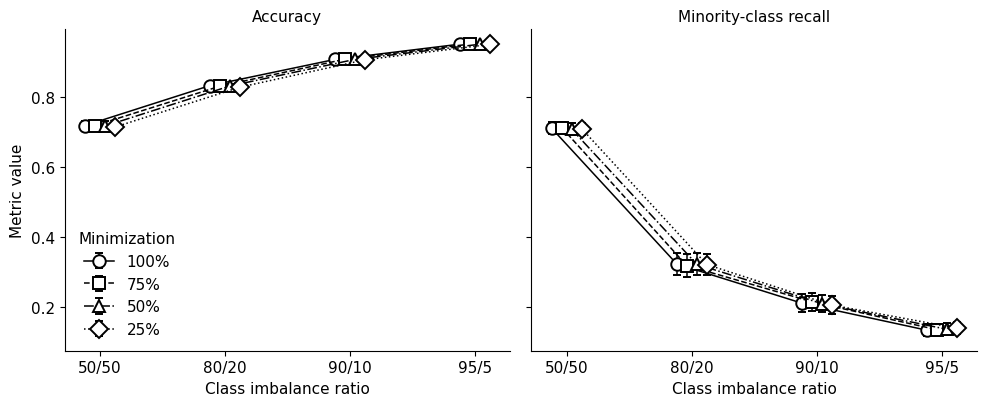

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, dv, title in [(axes[0], "accuracy", "Accuracy"),
                      (axes[1], "minority_recall", "Minority-class recall")]:
    for lvl in ["100", "75", "50", "25"]:
        sub = res[res["min_level"] == lvl]
        g = sub.groupby("imbalance", observed=True)[dv]
        m, ls, dx = STYLE[lvl]                      # three values now
        x = [i + dx for i in range(4)]              # dodged positions
        ax.errorbar(x, g.mean(), yerr=g.sem(), marker=m,
                    linestyle=ls, color="black",
                    markerfacecolor="white", markersize=9,
                    markeredgewidth=1.4, linewidth=1.1,
                    capsize=3, label=f"{lvl}%")
    ax.set_xticks(range(4))
    ax.set_xticklabels(["50/50", "80/20", "90/10", "95/5"])
    ax.set_xlabel("Class imbalance ratio")
    ax.set_title(title, fontsize=11)
axes[0].set_ylabel("Metric value")
axes[0].legend(title="Minimization")
fig.tight_layout()
fig.savefig("fig_rq3_contrast.png", dpi=300, bbox_inches="tight")

## Week 7 closeout: [2026-10-18]

All tables built in Word with captions registered; List of Tables and
List of Figures regenerated and audited against contents. Figures
archived (S3 /figures, repository figures/). Grayscale print test
passed. G*Power and W&B captures placed. Remaining inventory items are
external arrivals only: IRB determination letter (Appendix D) and the
chair's decision on the Appendix C consent placeholder (secondary
public data; consent not applicable under exempt status).